# Exercise Job Demand

In [27]:
# Import Libraries
from datasets import load_dataset as ld
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
raw = ld('lukebarousse/data_jobs')
df_original = raw['train'].to_pandas()
df = df_original.copy()

# Data Cleanning : Object/String to date convertion 
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [28]:
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"['python', 'go', 'nosql', 'sql', 'mongo', 'she...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


In [29]:
df['job_posted_month'] = df.job_posted_date.dt.strftime('%b')

In [30]:
df_US = df.pivot_table(index='job_posted_month',columns = 'job_title_short',aggfunc= 'size')
df_US

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
Apr,4246,1051,15514,14891,13513,990,2351,3572,2766,4025
Aug,5189,1378,18628,15622,16984,1360,2951,4025,4055,4970
Dec,4038,1152,13583,13303,12024,1254,1799,2878,2431,3841
Feb,3454,843,16558,15899,13951,1046,2713,3756,2994,3364
Jan,4874,1295,23585,21419,20760,1386,3696,5041,4644,5122
Jul,3850,1059,16095,14518,14177,1174,2380,3744,3117,3663
Jun,3413,714,16008,15501,13615,1048,2319,3809,2932,2213
Mar,3393,883,16243,16093,13569,1065,2454,3705,2987,3692
May,2408,480,13423,13646,11745,811,1925,3298,2399,1969


In [31]:
df_US.reset_index(inplace=True)
df_US['Month_no']=pd.to_datetime(df_US['job_posted_month'],format='%b').dt.month
df_US

job_title_short,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Month_no
0,Apr,4246,1051,15514,14891,13513,990,2351,3572,2766,4025,4
1,Aug,5189,1378,18628,15622,16984,1360,2951,4025,4055,4970,8
2,Dec,4038,1152,13583,13303,12024,1254,1799,2878,2431,3841,12
3,Feb,3454,843,16558,15899,13951,1046,2713,3756,2994,3364,2
4,Jan,4874,1295,23585,21419,20760,1386,3696,5041,4644,5122,1
5,Jul,3850,1059,16095,14518,14177,1174,2380,3744,3117,3663,7
6,Jun,3413,714,16008,15501,13615,1048,2319,3809,2932,2213,6
7,Mar,3393,883,16243,16093,13569,1065,2454,3705,2987,3692,3
8,May,2408,480,13423,13646,11745,811,1925,3298,2399,1969,5
9,Nov,4751,1268,15230,14947,14220,1305,2117,3597,2788,4227,11


In [32]:
df_US.sort_values('Month_no',inplace=True)
df_US


job_title_short,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Month_no
4,Jan,4874,1295,23585,21419,20760,1386,3696,5041,4644,5122,1
3,Feb,3454,843,16558,15899,13951,1046,2713,3756,2994,3364,2
7,Mar,3393,883,16243,16093,13569,1065,2454,3705,2987,3692,3
0,Apr,4246,1051,15514,14891,13513,990,2351,3572,2766,4025,4
8,May,2408,480,13423,13646,11745,811,1925,3298,2399,1969,5
6,Jun,3413,714,16008,15501,13615,1048,2319,3809,2932,2213,6
5,Jul,3850,1059,16095,14518,14177,1174,2380,3744,3117,3663,7
1,Aug,5189,1378,18628,15622,16984,1360,2951,4025,4055,4970,8
11,Sep,4447,1022,14969,14918,13577,1250,2194,3547,2936,3499,9
10,Oct,5000,1186,16239,15484,14151,1391,2317,3591,2908,4344,10


In [33]:
df_US.set_index('job_posted_month',inplace=True)
df_US.drop('Month_no',axis=1,inplace=True)
df_US

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
Jan,4874,1295,23585,21419,20760,1386,3696,5041,4644,5122
Feb,3454,843,16558,15899,13951,1046,2713,3756,2994,3364
Mar,3393,883,16243,16093,13569,1065,2454,3705,2987,3692
Apr,4246,1051,15514,14891,13513,990,2351,3572,2766,4025
May,2408,480,13423,13646,11745,811,1925,3298,2399,1969
Jun,3413,714,16008,15501,13615,1048,2319,3809,2932,2213
Jul,3850,1059,16095,14518,14177,1174,2380,3744,3117,3663
Aug,5189,1378,18628,15622,16984,1360,2951,4025,4055,4970
Sep,4447,1022,14969,14918,13577,1250,2194,3547,2936,3499


In [41]:
top_3 = df.job_title_short.value_counts().head(3).index
top_3 =top_3.to_list()
top_3

['Data Analyst', 'Data Engineer', 'Data Scientist']

Text(0, 0.5, 'Job Count')

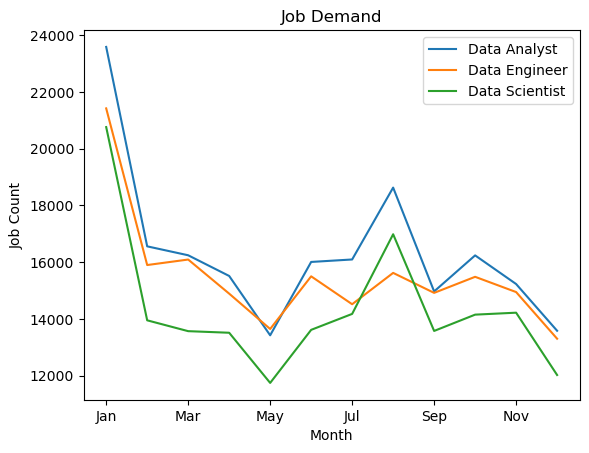

In [48]:
df_US_top3= df_US[top_3]
df_US_top3.plot(kind='line')
plt.legend()
plt.title('Job Demand')
plt.xlabel('Month')
plt.ylabel('Job Count')